# LeetCode #201: Bitwise AND of Numbers Range

https://leetcode.com/problems/bitwise-and-of-numbers-range/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(1)$ |
| **Common Prefix (Right Shift)** ★ | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
AND every integer from `left` to `right` sequentially. For large ranges (e.g., left=1, right=2^31-1) this iterates billions of times — completely impractical.

### Optimal: Common Prefix (Right Shift) ★
Any bit that differs between `left` and `right` must pass through both 0 and 1 in the range, so it ANDs to 0. Right-shift both values until they are equal; the equal portion is the common binary prefix. Shift it back left by the same amount.

**Why this is better than Brute Force:** Instead of AND-ing up to $2^{31}$ values, it finds the common prefix in at most 32 shifts — $O(\log n)$ vs $O(n)$.

**Constraints:**
* `0 <= left <= right <= 2^31 - 1`

## Solutions

### C#

In [ ]:
public int RangeBitwiseAnd(int left, int right) {
    int shift = 0;
    // Strip differing low-order bits until both values share the same prefix
    while (left != right) {
        left >>= 1;
        right >>= 1;
        shift++;
    }
    // Restore the common prefix to its original bit position
    return left << shift;
}

### Python

In [ ]:
def rangeBitwiseAnd(self, left: int, right: int) -> int:
    shift = 0
    # Keep shifting right until left and right share the same prefix
    while left != right:
        left >>= 1
        right >>= 1
        shift += 1
    # Shift back left to restore the prefix to its correct position
    return left << shift

### Go

In [ ]:
func rangeBitwiseAnd(left int, right int) int {
    shift := 0
    // Trim mismatched low bits by right-shifting until the common prefix emerges
    for left != right {
        left >>= 1
        right >>= 1
        shift++
    }
    // Left-shift back to place the prefix at the original bit width
    return left << shift
}

### Rust

In [ ]:
pub fn range_bitwise_and(mut left: i32, mut right: i32) -> i32 {
    let mut shift = 0;
    // Right-shift until left equals right, revealing the common prefix
    while left != right {
        left >>= 1;
        right >>= 1;
        shift += 1;
    }
    // Restore prefix to its original position by shifting left
    left << shift
}

## Example Scenarios

**1. Common Case**
**Input:** left = 5 (101), right = 7 (111)
After 1 shift: left=2 (10), right=3 (11). After 2 shifts: left=1 (1), right=1 (1). Equal at shift=2. Result = 1 << 2 = **4** (100). Range 5,6,7 AND = 101&110&111 = 100 ✓.

**2. Slightly Complex**
**Input:** left = 26 (11010), right = 30 (11110)
Two shifts needed (low 2 bits differ). Common prefix = 110 in binary = 6. Result = 6 << 2 = **24** (11000). Confirms that bits 0–1 all flip across the range, leaving bits 2+ as the prefix.

**3. Edge Case: Time Factor**
**Input:** left = 1, right = 2147483647
Left and right differ at every bit; all 31 shifts are needed. Each step is $O(1)$, so only 31 iterations total vs $\approx 2 \times 10^9$ brute-force iterations. Result = **0**.

**4. Edge Case: Space Factor**
**Input:** left = 0, right = 0
Loop never executes (left == right immediately). Returns 0 << 0 = **0**. Constant space, minimum input size.

**5. Almost-Impossible but Plausible**
**Input:** left = 2147483646, right = 2147483647
Both near $2^{31}$, differing only in bit 0. One shift: both become 1073741823. Common prefix = 1073741823 shifted left by 1 = **2147483646**. Even at max integer boundary, a single iteration suffices.

### Infographic

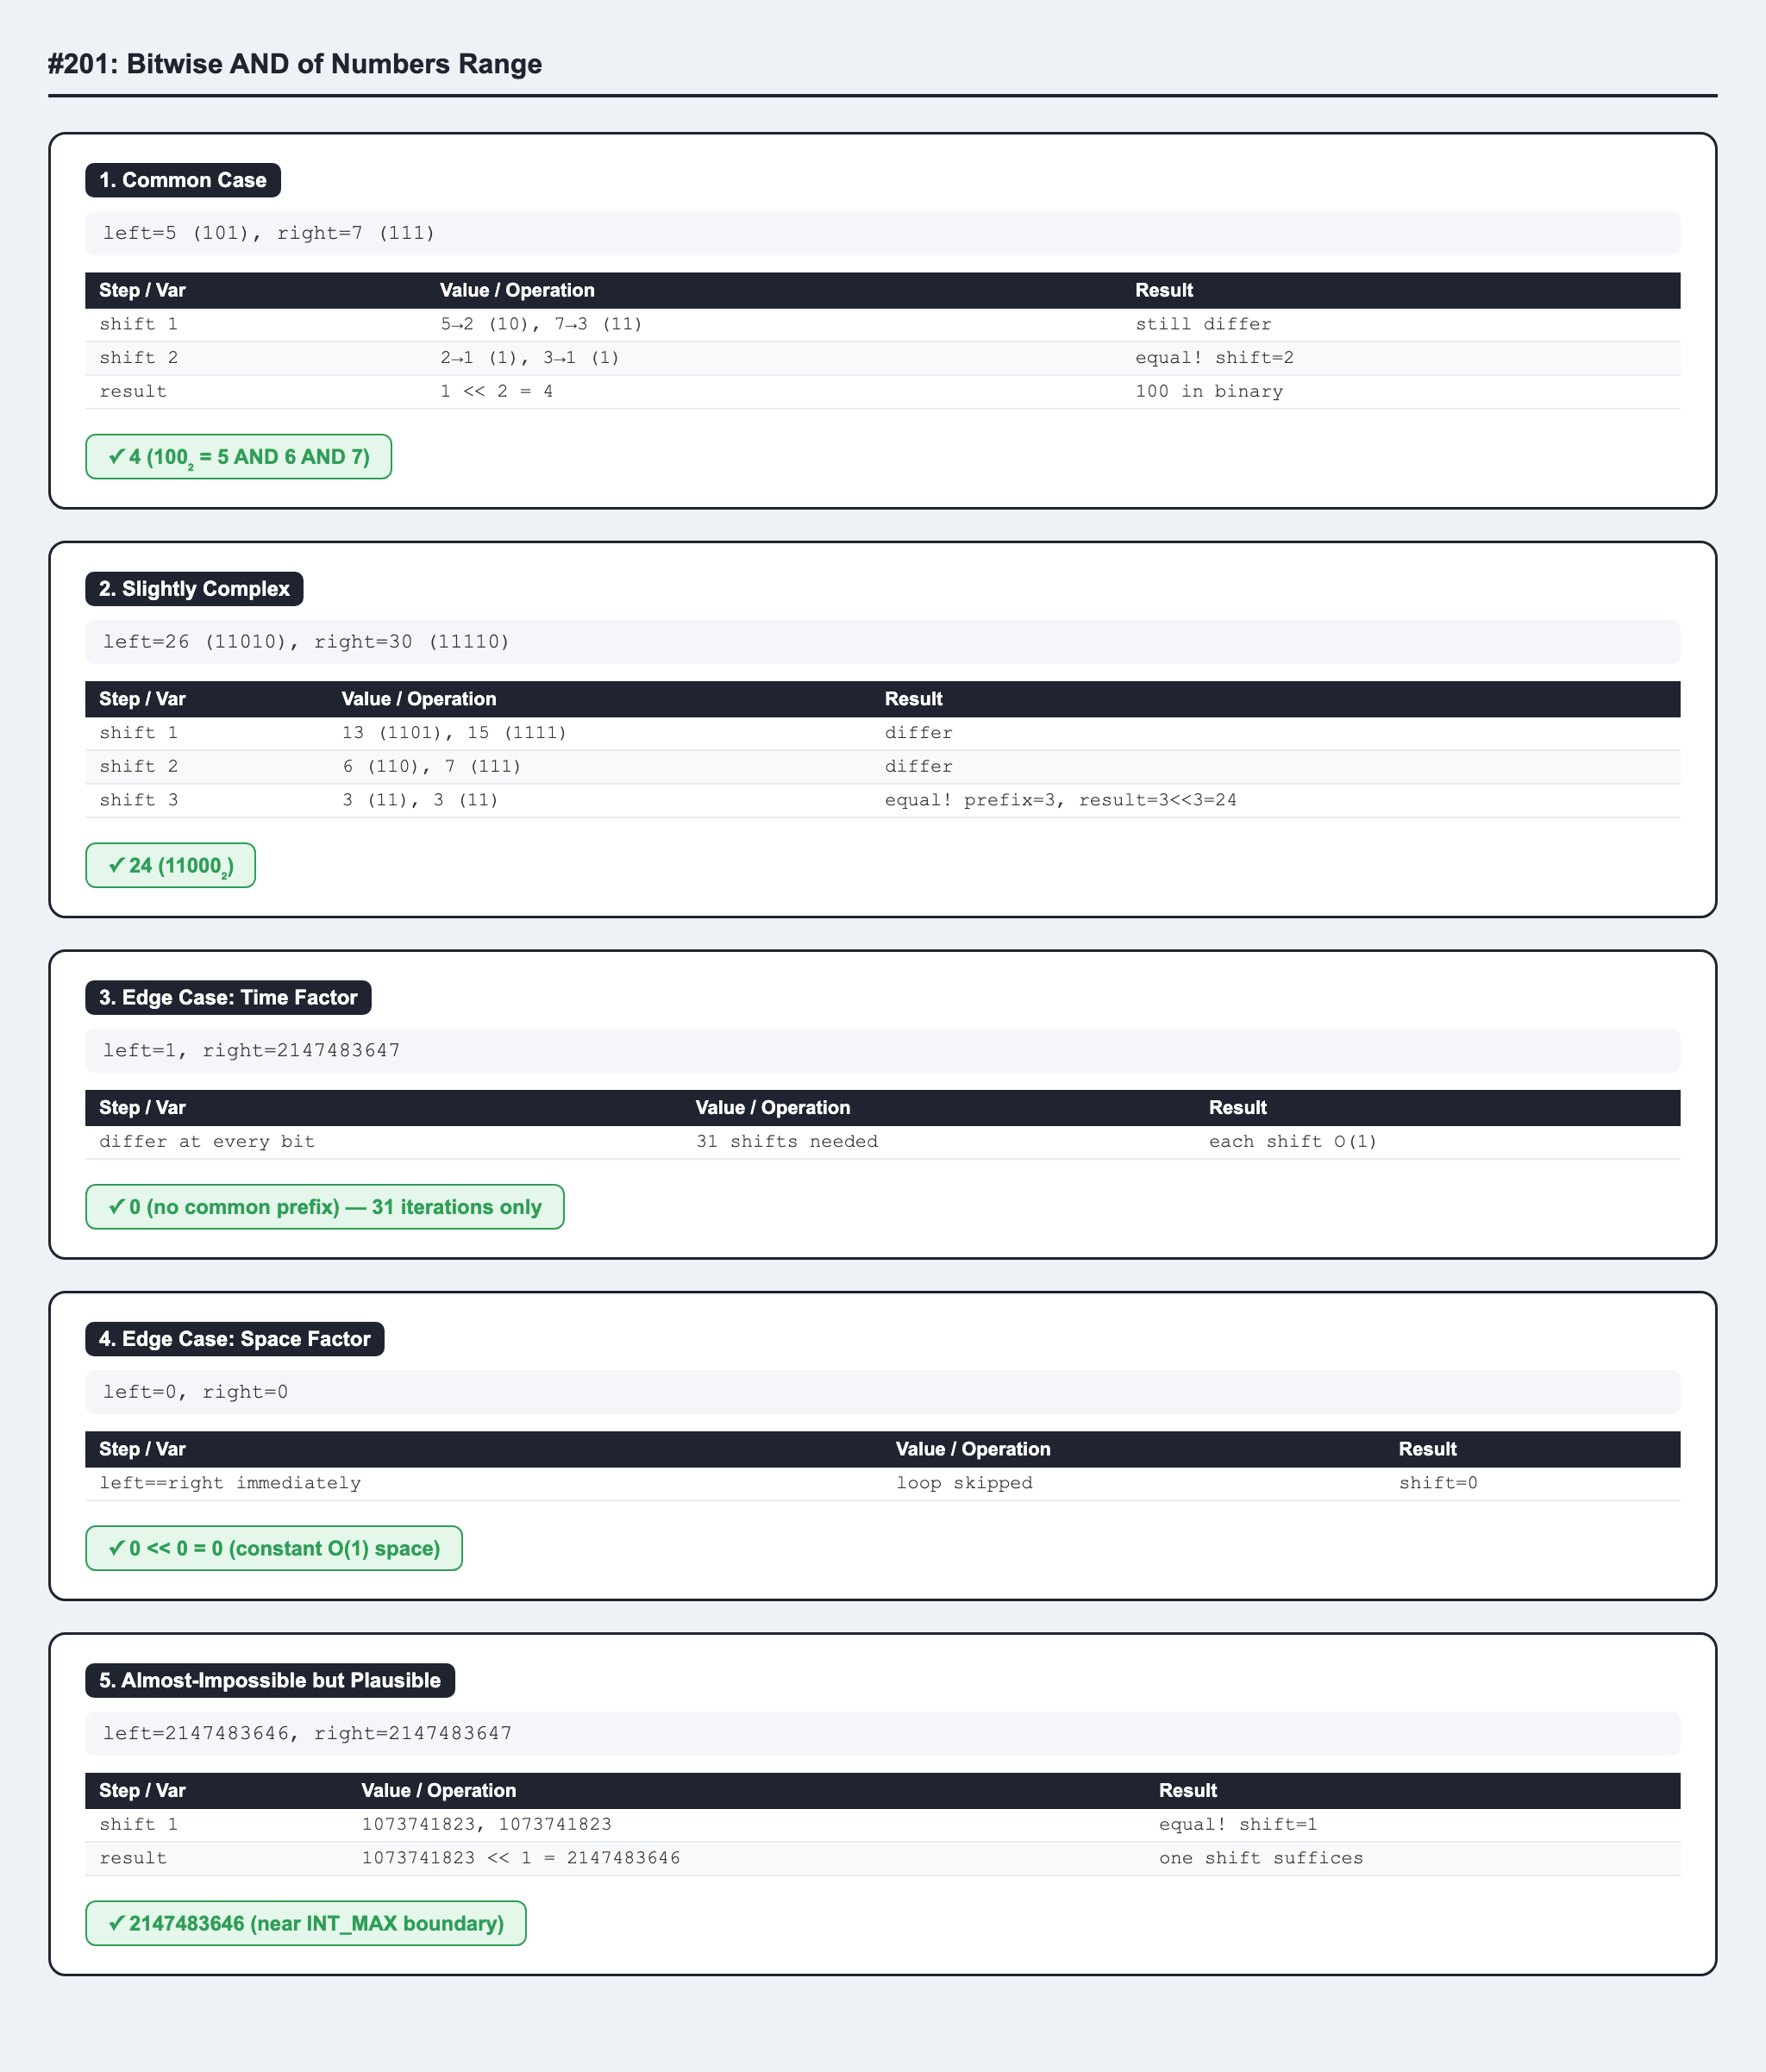